In [1]:
from matplotlib import pyplot as plt
import numpy as np
import xarray as xr
from mlpython.utils import compute_diss
plt.style.use('../grl.mplstyle')

In [2]:
path = "/Users/jiarongw/Data/multilayer_data/JPO2024/processed/ryang/"
tlist = np.array([110])
filelist = [path + f'/field{t}.nc' for t in tlist]
ds = xr.open_mfdataset(filelist, concat_dim='t', combine='nested')
ds = ds.assign_coords(t=tlist)
ds = compute_diss(ds).compute()

<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Field gradient computed!


Colorbar-like object skipped
Colorbar-like object skipped


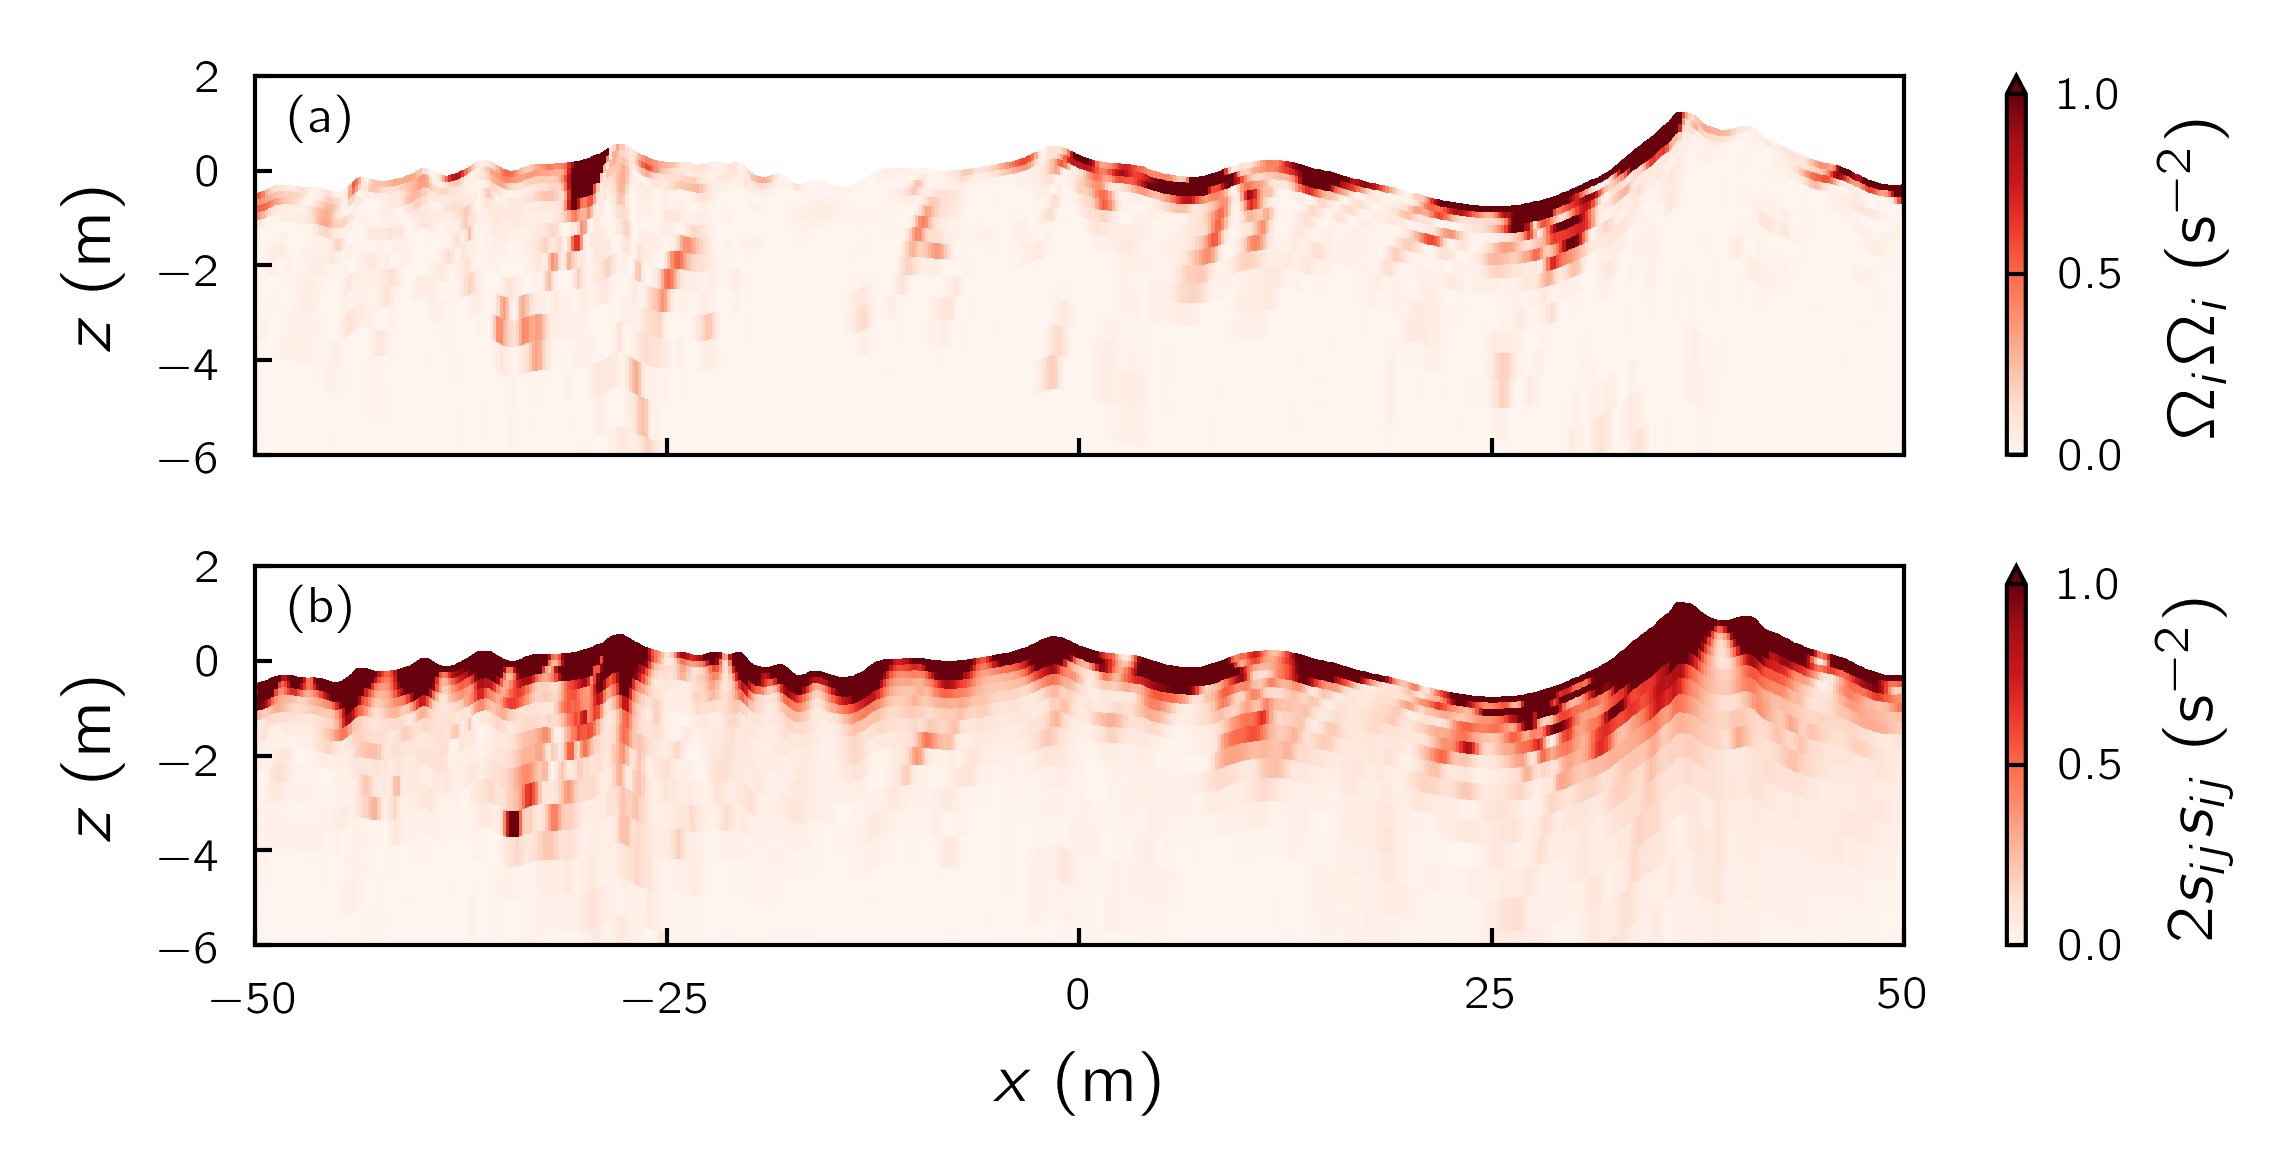

In [5]:
fig, axes = plt.subplots(2, 1, figsize=[4,2], sharex=True)
from mlpython.plot import set_letters

ds.vort2.isel(t=0,y=512).plot(x='x', y='z', ax=axes[0], vmax=1, vmin=0, cmap='Reds', 
                              cbar_kwargs={'label': r'$\Omega_{i}\Omega_{i} \; \mathrm{(s^{-2})}$'}, rasterized=True)
ds.epsilon.isel(t=0,y=512).plot(x='x', y='z', ax=axes[1], vmax=1, vmin=0, cmap='Reds', 
                                cbar_kwargs={'label': r'$2s_{ij}s_{ij} \; \mathrm{(s^{-2})}$'}, rasterized=True)
axes[0].set_ylim([-6,2]); axes[1].set_ylim([-6,2])
axes[1].set_xlim([-50,50]); axes[1].set_xticks([-50,-25,0,25,50])
axes[0].set_title(''); axes[1].set_title('')
axes[0].set_ylabel('$z \; (\mathrm{m})$'); axes[1].set_ylabel('$z \; (\mathrm{m})$')
axes[1].set_xlabel('$x \; (\mathrm{m})$'); axes[0].set_xlabel('')

set_letters(x=0.02, y=0.85, fontsize=6)
plt.tight_layout()
fig.savefig('../jpo2024/plots/ryang_t110_Omega_vs_sij.pdf', bbox_inches='tight')